In [1]:
import pandas as pd
import numpy as np
import sklearn

from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
import seaborn as sns



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\arham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df1=pd.read_csv('spam_ham_india.csv')
df1.rename(columns={'Msg':'text', 'Label':'target'}, inplace=True)


df1['target']=encoder.fit_transform(df1['target'])


In [3]:
df2=pd.read_csv('cleaned_sms_spam.csv')
df2.drop(columns=['Unnamed: 0'], inplace=True)
print(df1['target'].value_counts())
print(df2['target'].value_counts())
df=pd.concat([df1,df2], ignore_index=True)
print(df.shape)
df.sample(20)

target
0    1522
1     745
Name: count, dtype: int64
target
0    4516
1     653
Name: count, dtype: int64
(7436, 2)


,text,target
6881,hi baby im sat on the bloody bus at the mo and...,0
6786,"Awesome, that gonna be soon or later tonight?",0
7065,Pls call me da. What happen.,0
4887,R Ì_ going 4 today's meeting?,0
769,Although it may not be that favorable the chan...,0
607,Yes we'll have to go over it a few times,0
1768,News,0
4006,"If we hit it off, you can move in with me :)",0
4493,On the way to office da..,0
771,This can be considered the rebound phase after...,0


In [4]:
df['text'].apply(lambda x: isinstance(x,(int, float))).value_counts()

text
False    7435
True        1
Name: count, dtype: int64

In [5]:
# df.drop(index=df[df['text'].apply(lambda x: isinstance(x,(int, float)))].index, inplace=True)
# df['text'].apply(lambda x: isinstance(x,(int, float))).value_counts()


In [6]:
df.drop(index=df[df['text'].apply(lambda x: isinstance(x,(int, float)))].index, inplace=True)

In [7]:
df.head()

,text,target
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1
1,Hi! Thank you for being with Vi-India's FASTES...,1
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1
3,I will try to manage took tablets,0
4,Study from Home with Vi!! Watch Kite Victers C...,1


In [8]:
df['target'].value_counts()

target
0    6037
1    1398
Name: count, dtype: int64

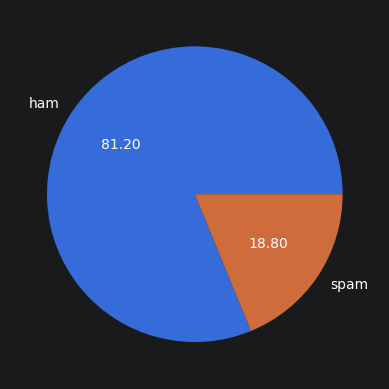

In [9]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct='%0.2f')
plt.show()

In [14]:
df.to_csv("data.csv", index=False, encoding='utf-8')

In [10]:

df['num_characters'] = df['text'].apply(lambda x: len((str(x).replace(" ", ""))))
df.head()

,text,target,num_characters
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90
1,Hi! Thank you for being with Vi-India's FASTES...,1,131
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123
3,I will try to manage took tablets,0,27
4,Study from Home with Vi!! Watch Kite Victers C...,1,115


In [11]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(str(x))))
df.head()

,text,target,num_characters,num_words
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27
3,I will try to manage took tablets,0,27,7
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28


In [12]:
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(str(x))))
df.head()


,text,target,num_characters,num_words,num_sentences
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17,4
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30,4
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27,2
3,I will try to manage took tablets,0,27,7,1
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28,4


In [15]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,6037.000000,6037.000000,6037.000000
mean,56.357959,15.975650,1.689747
std,55.440344,14.702897,1.279904
min,1.000000,1.000000,1.000000
25%,25.000000,7.000000,1.000000
50%,40.000000,12.000000,1.000000
75%,70.000000,20.000000,2.000000
max,740.000000,220.000000,38.000000


In [16]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,1398.000000,1398.000000,1398.000000
mean,128.658083,29.968526,3.000000
std,41.709348,11.836231,2.512674
min,12.000000,2.000000,1.000000
25%,113.000000,25.000000,2.000000
50%,127.000000,29.000000,3.000000
75%,134.000000,33.000000,4.000000
max,537.000000,193.000000,52.000000


<Axes: xlabel='num_characters', ylabel='Count'>

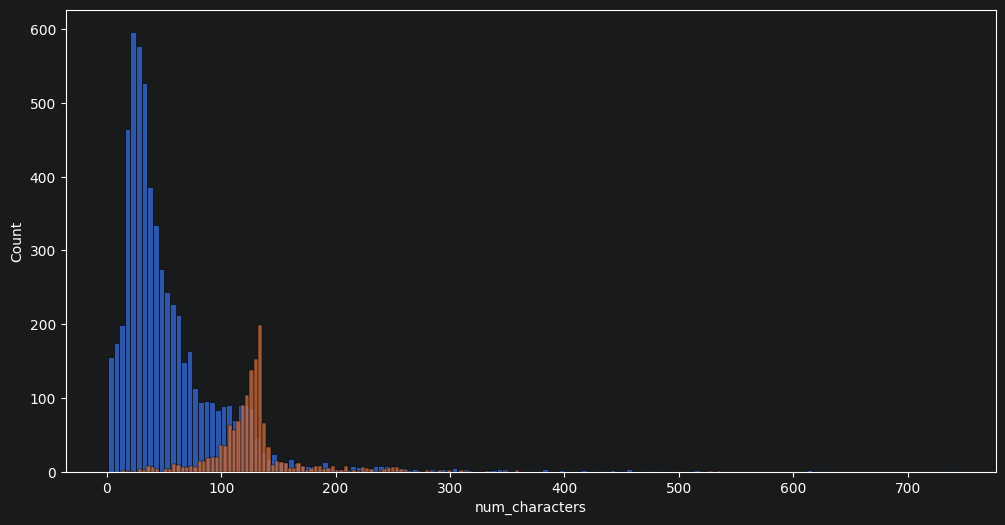

In [17]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'])

<Axes: xlabel='num_words', ylabel='Count'>

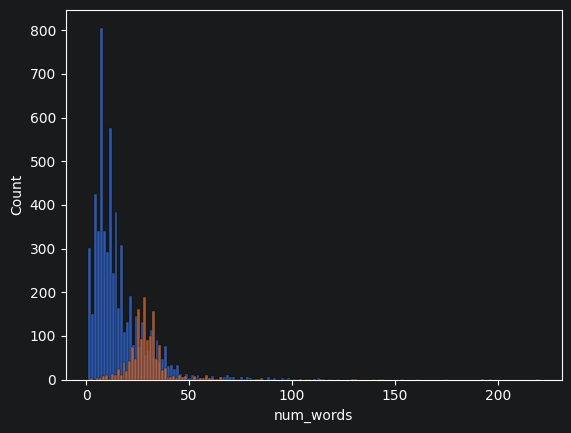

In [18]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'])

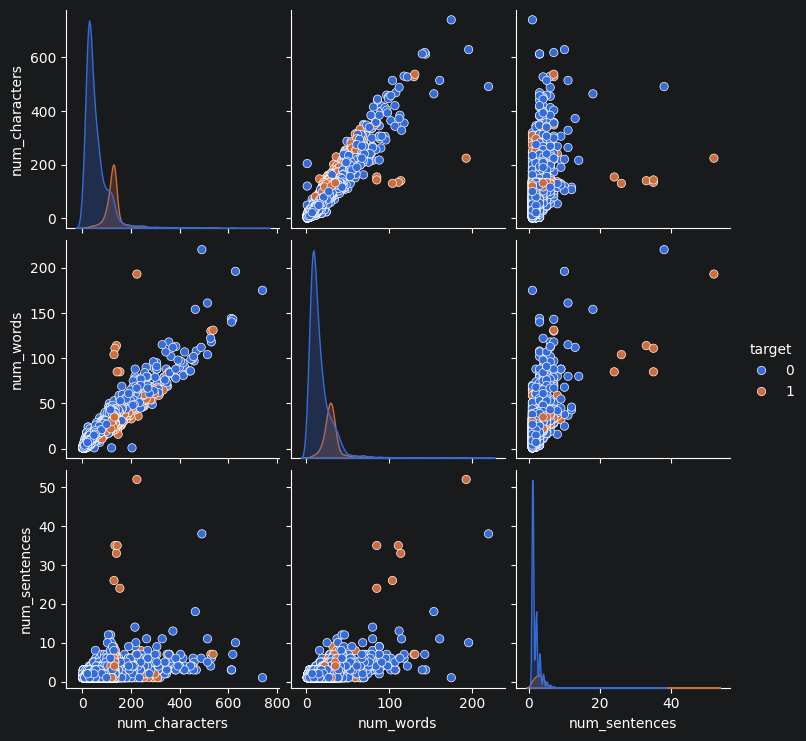

In [19]:
sns.pairplot(df,hue='target')

<Axes: >

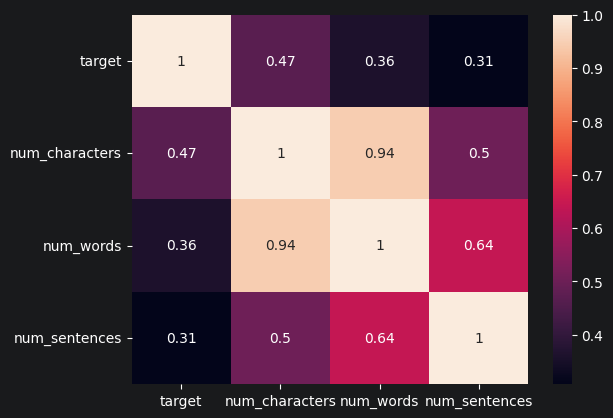

In [20]:
sns.heatmap(df.drop(columns=['text']).corr(), annot=True)

In [21]:
#here we can observe num of words, num of chars and num of sentences are highly correlated with each other. so we can drop any 2 of them and keep one feature for our model. we will keep num_characters and drop the other two features as it has highest correlation with target variable.

## Text Preprocessing
1. lower case
2. tokenization
3. removing special characters
4. removing stopwords and punctuations
5. removing words with same meaning (stemming)

In [22]:
from nltk.corpus import stopwords
stopwords.words('english')


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [23]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [24]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('playing')

'play'

In [25]:
def text_pp(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [26]:
text_pp('hi my name is arham, and i love to play cricket. what do you like?')

'hi name arham love play cricket like'

In [27]:
text_pp('1047956&%')

'1047956'

In [28]:
df['transformed_text']=df['text'].apply(text_pp)
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17,4,congratul free 2gb data claim airtel thank app...
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30,4,hi thank fastest 4g love improv click http sha...
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27,2,part cyber swachhta pakhwada goi advis keep di...
3,I will try to manage took tablets,0,27,7,1,tri manag took tablet
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28,4,studi home vi watch kite victer channel free m...


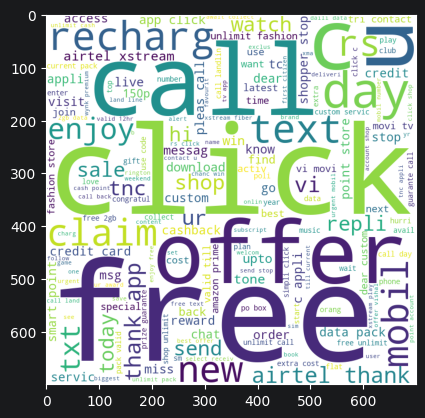

In [29]:
from wordcloud import WordCloud
wc=WordCloud(width=700, height=700, min_font_size=10, background_color='white')
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

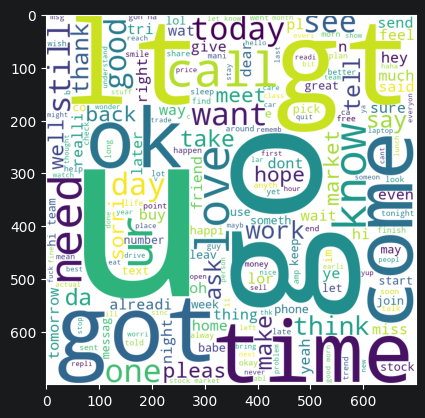

In [30]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [31]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,CONGRATULATIONS! FREE 2GB data is yours! Claim...,1,90,17,4,congratul free 2gb data claim airtel thank app...
1,Hi! Thank you for being with Vi-India's FASTES...,1,131,30,4,hi thank fastest 4g love improv click http sha...
2,"As part of Cyber Swachhta Pakhwada, CERT-In Go...",1,123,27,2,part cyber swachhta pakhwada goi advis keep di...
3,I will try to manage took tablets,0,27,7,1,tri manag took tablet
4,Study from Home with Vi!! Watch Kite Victers C...,1,115,28,4,studi home vi watch kite victer channel free m...


In [32]:
df[df['target']==1]['transformed_text']


0       congratul free 2gb data claim airtel thank app...
1       hi thank fastest 4g love improv click http sha...
2       part cyber swachhta pakhwada goi advis keep di...
4       studi home vi watch kite victer channel free m...
8       hi 1 new home loan offer rate start low emi rs...
                              ...                        
7404    want explicit sex 30 sec ring 02073162414 cost...
7406    ask 3mobil 0870 chatlin inclu free min india c...
7413    contract mobil 11 mnth latest motorola nokia e...
7430    remind o2 get pound free call credit detail gr...
7431    2nd time tri 2 contact u pound prize 2 claim e...
Name: transformed_text, Length: 1398, dtype: object

In [33]:
df[df['target']==1]['transformed_text'].tolist()

['congratul free 2gb data claim airtel thank app hurri',
 'hi thank fastest 4g love improv click http share feedback',
 'part cyber swachhta pakhwada goi advis keep digit devic bot free get bot remov tool http',
 'studi home vi watch kite victer channel free mobil vi download vi movi tv app click',
 'hi 1 new home loan offer rate start low emi rs appli tnc appli',
 'summer heat get ac air cooler fridg pay later cost use feder bank debit card emi click http latest offer bank',
 'let secur concern ruin travel plan get airtel enabl surveil solut send real time alert order get free instal',
 'rs299 recharg enjoy unlimit valid 28 1 yr zee5 premium subscript credit activ click',
 '1 step away free router get airtel xstream fiber enjoy 1 gbp speed devic plan start rs 499',
 'diwali let big save get 75 salari withdraw upto 3000 offer valid 25th sign team refyn',
 'big bull star abhishek bachchan dekhiy hotstar vip par vi ke nay 401 recharg pe paiy 1yr hotstar vip 100gb data unlimit call 28day 

In [34]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
print(spam_corpus)

#this gives us a corpus of words that appear in spam messages

['congratul', 'free', '2gb', 'data', 'claim', 'airtel', 'thank', 'app', 'hurri', 'hi', 'thank', 'fastest', '4g', 'love', 'improv', 'click', 'http', 'share', 'feedback', 'part', 'cyber', 'swachhta', 'pakhwada', 'goi', 'advis', 'keep', 'digit', 'devic', 'bot', 'free', 'get', 'bot', 'remov', 'tool', 'http', 'studi', 'home', 'vi', 'watch', 'kite', 'victer', 'channel', 'free', 'mobil', 'vi', 'download', 'vi', 'movi', 'tv', 'app', 'click', 'hi', '1', 'new', 'home', 'loan', 'offer', 'rate', 'start', 'low', 'emi', 'rs', 'appli', 'tnc', 'appli', 'summer', 'heat', 'get', 'ac', 'air', 'cooler', 'fridg', 'pay', 'later', 'cost', 'use', 'feder', 'bank', 'debit', 'card', 'emi', 'click', 'http', 'latest', 'offer', 'bank', 'let', 'secur', 'concern', 'ruin', 'travel', 'plan', 'get', 'airtel', 'enabl', 'surveil', 'solut', 'send', 'real', 'time', 'alert', 'order', 'get', 'free', 'instal', 'rs299', 'recharg', 'enjoy', 'unlimit', 'valid', '28', '1', 'yr', 'zee5', 'premium', 'subscript', 'credit', 'activ', '

In [35]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 468),
 ('free', 438),
 ('click', 421),
 ('get', 357),
 ('offer', 197),
 ('http', 190),
 ('2', 189),
 ('airtel', 182),
 ('data', 177),
 ('unlimit', 166),
 ('c', 156),
 ('day', 154),
 ('app', 153),
 ('claim', 152),
 ('mobil', 147),
 ('rs', 141),
 ('txt', 141),
 ('stop', 136),
 ('recharg', 133),
 ('shop', 128),
 ('u', 128),
 ('ur', 127),
 ('text', 122),
 ('1', 116),
 ('pack', 115),
 ('vi', 112),
 ('4', 111),
 ('enjoy', 106),
 ('repli', 105),
 ('store', 104)]

In [36]:
pd.DataFrame(Counter(spam_corpus).most_common(30))


,0,1
0,call,468
1,free,438
2,click,421
3,get,357
4,offer,197
5,http,190
6,2,189
7,airtel,182
8,data,177
9,unlimit,166


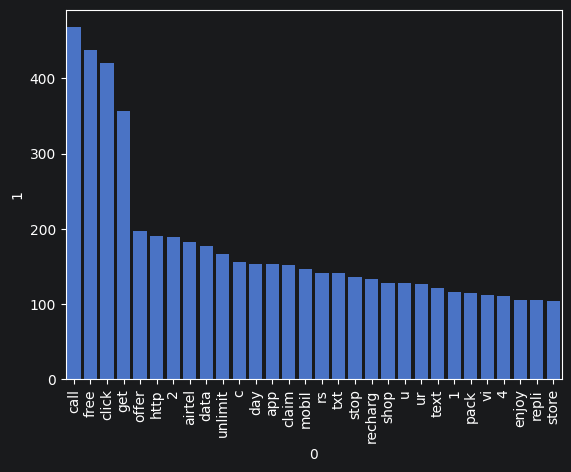

In [37]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [38]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
print(ham_corpus)

['tri', 'manag', 'took', 'tablet', 'get', 'fix', 'asap', 'imag', 'omit', 'sure', 'join', 'tomorrow', 'morn', 'hi', 'start', 'discuss', 'topic', 'happi', '2021', 'one', 'may', 'obstruct', 'constraint', 'remov', 'may', 'clariti', 'peac', 'mind', 'healthi', 'bodi', 'new', 'year', 'work', 'infront', 'ac', 'fortun', 'buy', 'paytm', 'week', 'turn', 'profit', 'msg', 'sent', 'mistak', 'learn', 'make', 'peopl', 'grow', 'continu', 'enough', 'knowledg', 'gain', 'firm', 'foothold', 'market', 'matter', 'field', 'need', 'keep', 'learn', 'knowledg', 'capit', 'accumul', 'wealth', 'ye', 'trend', 'consist', 'upward', 'make', 'profit', 'share', 'tonight', 'tomorrow', 'night', 'bought', '200', 'share', 'good', 'even', 'index', 'adjust', 'usual', 'follow', 'gradual', 'inclus', 'process', 'inflow', 'fund', 'also', 'carri', 'stage', 'hi', 'team', 'hi', 'team', 'haha', 'anyway', 'professor', 'compens', 'afraid', 'make', 'profit', 'best', 'outcom', 'least', 'wo', 'make', 'professor', 'spend', 'earn', 'market',

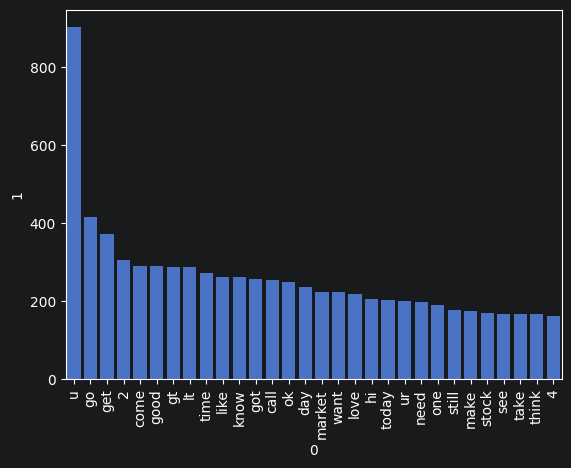

In [39]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

## Text Vectorisation

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()


In [41]:
X=tfidf.fit_transform(df['transformed_text']).toarray()
print(X.shape)
y=df['target']

(7435, 8396)


In [42]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)


In [44]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_pred1,y_test))
print(confusion_matrix(y_pred1,y_test))
print(precision_score(y_pred1,y_test))



0.7908540685944856
[[910  16]
 [295 266]]
0.9432624113475178


In [45]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_pred2,y_test))
print(confusion_matrix(y_pred2,y_test))
print(precision_score(y_pred2,y_test))

0.9751176866173503
[[1202   34]
 [   3  248]]
0.8794326241134752


In [46]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_pred3,y_test))
print(confusion_matrix(y_pred3,y_test))
print(precision_score(y_pred3,y_test))

0.9778076664425017
[[1204   32]
 [   1  250]]
0.8865248226950354


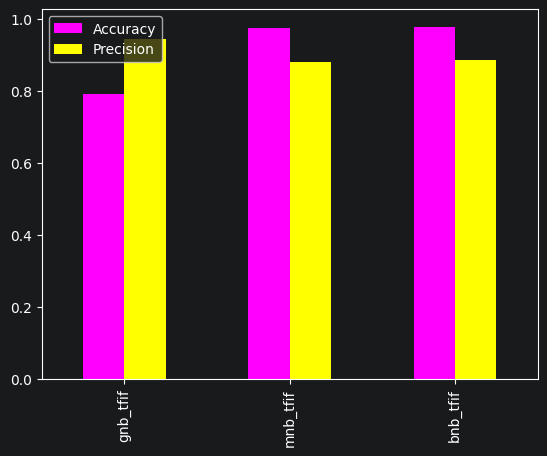

In [47]:

data1 = {
    "gnb_tfif": [accuracy_score(y_pred1, y_test), precision_score(y_pred1,y_test)],
    "mnb_tfif": [accuracy_score(y_pred2, y_test), precision_score(y_pred2,y_test)],
    "bnb_tfif": [accuracy_score(y_pred3, y_test), precision_score(y_pred3,y_test)]
}
pd.DataFrame(data1,index=['Accuracy','Precision']).T.plot(kind='bar',color=['magenta','yellow'])
plt.show()

# Above graph shows the model statistics for the Gaussian, Multinomial and Bernoulli's distribution for Naive-Baye's classifier when TF-IDF Vectorisation is used.

In [48]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

X1=cv.fit_transform(df['transformed_text']).toarray()
y1=df['target']

In [49]:
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=2)


In [50]:
gnb.fit(X1_train,y1_train)
y1_pred1=gnb.predict(X_test)
print(accuracy_score(y1_pred1,y1_test))
print(confusion_matrix(y1_pred1,y1_test))
print(precision_score(y1_pred1,y1_test))

0.7901815736381977
[[909  16]
 [296 266]]
0.9432624113475178


In [51]:
mnb.fit(X1_train,y1_train)
y1_pred2=mnb.predict(X1_test)
print(accuracy_score(y1_pred2,y1_test))
print(confusion_matrix(y1_pred2,y1_test))
print(precision_score(y1_pred2,y1_test))

0.9784801613987895
[[1185   12]
 [  20  270]]
0.9574468085106383


In [52]:
bnb.fit(X1_train,y1_train)
y1_pred3=bnb.predict(X1_test)
print(accuracy_score(y1_pred3,y1_test))
print(confusion_matrix(y1_pred3,y1_test))
print(precision_score(y1_pred3,y1_test))

0.9778076664425017
[[1204   32]
 [   1  250]]
0.8865248226950354


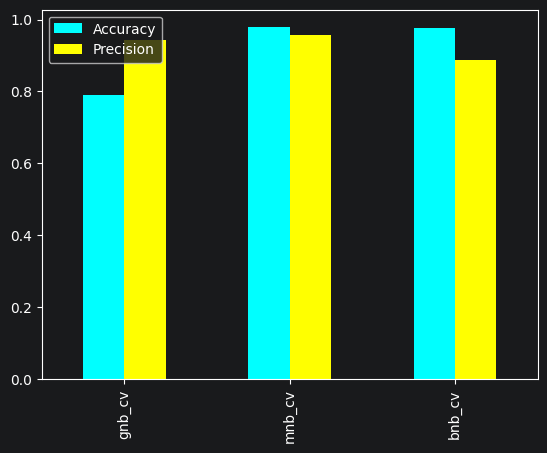

In [53]:
data2 = {
    "gnb_cv": [accuracy_score(y1_pred1, y1_test), precision_score(y1_pred1,y1_test)],
    "mnb_cv": [accuracy_score(y1_pred2, y1_test), precision_score(y1_pred2,y1_test)],
    "bnb_cv": [accuracy_score(y1_pred3, y1_test), precision_score(y1_pred3,y1_test)]
}
pd.DataFrame(data2,index=['Accuracy','Precision']).T.plot(kind='bar',color=['cyan','yellow'])
plt.show()

From the above two tables, its clear that Multinomial Naive-Baye's trained on Bag of Words Vectorization is giving best results of all six.

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier


In [55]:
nb=MultinomialNB()
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)


In [56]:
clfs={
    'Naive-Bayes':nb,
    'RandomForestClassifier':rfc,
    'ExtraTreeClassifier':etc,
    'AdaBoost':abc
}
def predic(classifier,X_train,X_test,y_train,y_test):
    classifier.fit(X_train,y_train)
    y_pred=classifier.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test,y_pred)
    return acc,prec


accuracy_sc_tfidf=[]
accuracy_sc_bow=[]
precision_sc_tfidf=[]
precision_sc_bow=[]

for clf in clfs.values():
    accu,preci=predic(clf,X_train,X_test,y_train,y_test)
    accuracy_sc_tfidf.append(accu)
    precision_sc_tfidf.append(preci)
    accu,preci=predic(clf,X1_train,X1_test,y1_train,y1_test)
    accuracy_sc_bow.append(accu)
    precision_sc_bow.append(preci)



performance_df=pd.DataFrame({'Model':clfs.keys(),'Accuracy TFIDF':accuracy_sc_tfidf,'Precision TFIDF':precision_sc_tfidf,'Accuracy BOW':accuracy_sc_bow,'Precision BOW':precision_sc_bow})


In [57]:
performance_df.head()

,Model,Accuracy TFIDF,Precision TFIDF,Accuracy BOW,Precision BOW
0,Naive-Bayes,0.975118,0.988048,0.978480,0.931034
1,RandomForestClassifier,0.979825,0.984615,0.973773,0.984064
2,ExtraTreeClassifier,0.976463,0.969582,0.977808,0.973384
3,AdaBoost,0.905178,0.993007,0.905178,0.993007


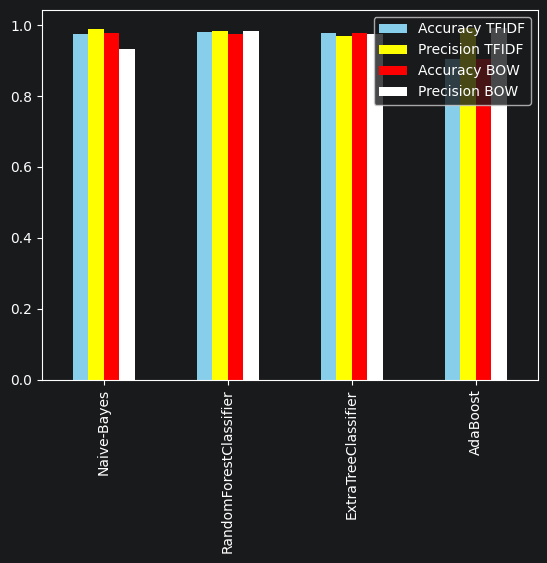

In [58]:
performance_df.index=clfs.keys()
a=performance_df.head().plot(kind='bar',color=['skyblue','yellow','red','white'])
plt.show()

# In a side by side comparision, we can observe that the TFIDF Vectorisation is giving better overall results as compared to Bag of Words.

In [59]:
tfidf_=TfidfVectorizer(max_features=2000)

In [60]:
X2 = tfidf_.fit_transform(df['transformed_text']).toarray()
print(X2.shape)
y2 = df['target']

(7435, 2000)


In [61]:
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.2,random_state=42)

In [62]:
X2_train,X2_test,y2_train,y2_test = train_test_split(X2,y2,test_size=0.2,random_state=40)
accuracy_mp=[]
precision_mp=[]
for clf in clfs.values():
    accu,preci=predic(clf,X2_train,X2_test,y2_train,y2_test)
    accuracy_mp.append(accu)
    precision_mp.append(preci)
performance_df2=pd.DataFrame({'Model':clfs.keys(),'AccuracyTFIDF':accuracy_sc_tfidf,'PrecisionTFIDF':precision_sc_tfidf,'AccuracyTFIDF3000':accuracy_mp,'PrecisionTFIDF3000':precision_mp})
performance_df2.head()

,Model,AccuracyTFIDF,PrecisionTFIDF,AccuracyTFIDF3000,PrecisionTFIDF3000
0,Naive-Bayes,0.975118,0.988048,0.971755,0.950570
1,RandomForestClassifier,0.979825,0.984615,0.979153,0.992063
2,ExtraTreeClassifier,0.976463,0.969582,0.971755,0.954023
3,AdaBoost,0.905178,0.993007,0.905178,0.985915


In [63]:
from sklearn.ensemble import VotingClassifier
voting=VotingClassifier(estimators=[('nb',nb),('rf',rfc),('et',etc),('ab',abc)],voting='hard')
voting.fit(X2_train,y2_train)
y2_pred=voting.predict(X2_test)
print('Accuracy= ',accuracy_score(y2_pred,y2_test))
print('Precision= ',precision_score(y2_pred,y2_test))


Accuracy=  0.9731002017484869
Precision=  0.8566308243727598


In [74]:
estimators=[('rf',rfc),('et',etc),('ab',abc)]
final_estimator=MultinomialNB()

In [76]:
from sklearn.ensemble import StackingClassifier

In [77]:
clf=StackingClassifier(estimators=estimators,final_estimator=final_estimator)
clf.fit(X2_train,y2_train)


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('et', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",MultinomialNB()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples requir

In [78]:
y3_pred=clf.predict(X2_test)
print('Accuracy= ',accuracy_score(y2_test,y3_pred))
print('Precision= ',precision_score(y2_test,y3_pred))



Accuracy=  0.9697377269670477
Precision=  0.9957627118644068


# Out of all of these, Random Forest seems to be giving the best output overall so we will be using it

In [ ]:
import pickle
pickle.dump(tfidf_,open('Vectorizer.pkl',"wb"))
pickle.dump(rfc,open('model.pkl',"wb"))

In [81]:
#Versions
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", sklearn.__version__)
print("seaborn", sns.__version__)

numpy 2.1.3
pandas 2.2.3
sklearn 1.8.0
seaborn 0.13.2
